In [1]:
import pandas as pd
import numpy as np
import datetime as dt
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, davies_bouldin_score

df = pd.read_csv("online_retail.csv", encoding="ISO-8859-1")
print(df.shape)
df.head()

(1067371, 8)


,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085.0,United Kingdom
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085.0,United Kingdom
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085.0,United Kingdom


In [3]:
df = df.rename(columns={
    'Invoice': 'InvoiceNo',
    'Price': 'UnitPrice',
    'Customer ID': 'CustomerID'
})

df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'])
df['InvoiceNo'] = df['InvoiceNo'].astype(str)

df_clean = df.dropna(subset=['CustomerID']).copy()
df_clean = df_clean[
    ~df_clean['InvoiceNo'].str.startswith('C')
    & (df_clean['Quantity'] > 0)
    & (df_clean['UnitPrice'] > 0)
].drop_duplicates()

df_clean['CustomerID'] = df_clean['CustomerID'].astype(int)
df_clean['TotalPrice'] = df_clean['Quantity'] * df_clean['UnitPrice']

print(f"Rows kept: {len(df_clean):,} of {len(df):,}")
print(f"Unique customers: {df_clean['CustomerID'].nunique():,}")

Rows kept: 779,425 of 1,067,371
Unique customers: 5,878


In [4]:
snapshot_date = df_clean['InvoiceDate'].max() + dt.timedelta(days=1)

rfm = df_clean.groupby('CustomerID').agg(
    Recency=('InvoiceDate', lambda x: (snapshot_date - x.max()).days),
    Frequency=('InvoiceNo', 'nunique'),
    Monetary=('TotalPrice', 'sum')
)
print(rfm.shape)
rfm.describe().round(2)

(5878, 3)


,Recency,Frequency,Monetary
count,5878.00,5878.00,5878.00
mean,201.33,6.29,2955.90
std,209.34,13.01,14440.85
min,1.00,1.00,2.95
25%,26.00,1.00,342.28
50%,96.00,3.00,867.74
75%,380.00,7.00,2248.30
max,739.00,398.00,580987.04


Skew before:
 Recency       0.89
Frequency    12.64
Monetary     25.07
dtype: float64

Skew after:
 Recency     -0.49
Frequency    1.00
Monetary     0.27
dtype: float64


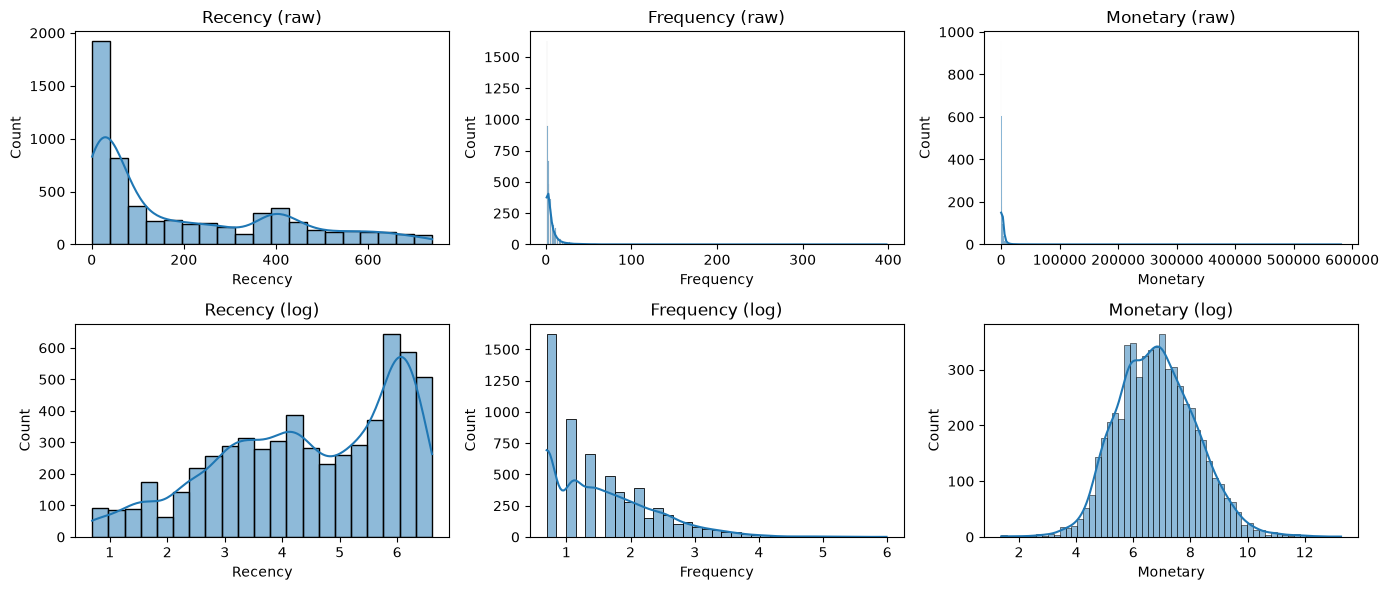

In [5]:
print("Skew before:\n", rfm.skew().round(2))

rfm_log = np.log1p(rfm)
print("\nSkew after:\n", rfm_log.skew().round(2))

fig, axes = plt.subplots(2, 3, figsize=(14, 6))
for i, col in enumerate(rfm.columns):
    sns.histplot(rfm[col], ax=axes[0, i], kde=True)
    axes[0, i].set_title(f"{col} (raw)")
    sns.histplot(rfm_log[col], ax=axes[1, i], kde=True)
    axes[1, i].set_title(f"{col} (log)")
plt.tight_layout()
plt.show()

In [6]:
scaler = StandardScaler()
X = scaler.fit_transform(rfm_log)
print(X.mean(axis=0).round(2), X.std(axis=0).round(2))

[-0.  0.  0.] [1. 1. 1.]


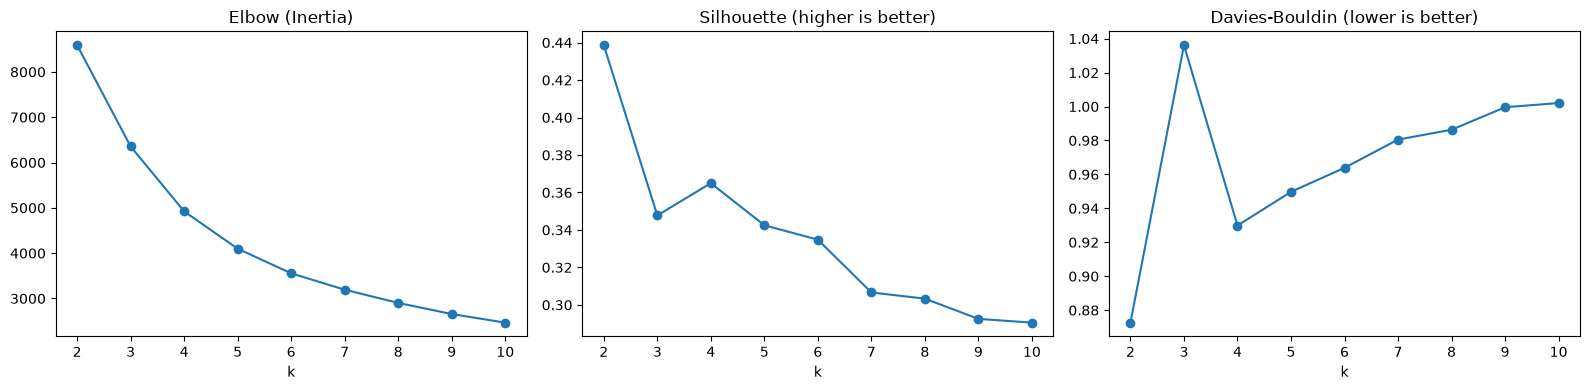

,k,inertia,silhouette,davies_bouldin
0,2,8588.985,0.439,0.873
1,3,6354.343,0.348,1.036
2,4,4921.233,0.365,0.930
3,5,4099.106,0.342,0.950
4,6,3554.696,0.335,0.964
5,7,3194.501,0.307,0.981
6,8,2902.434,0.303,0.986
7,9,2656.562,0.293,1.000
8,10,2467.378,0.291,1.002


In [7]:
k_range = range(2, 11)
inertia, sil, dbi = [], [], []

for k in k_range:
    km = KMeans(n_clusters=k, n_init=10, random_state=42)
    labels = km.fit_predict(X)
    inertia.append(km.inertia_)
    sil.append(silhouette_score(X, labels))
    dbi.append(davies_bouldin_score(X, labels))

fig, axes = plt.subplots(1, 3, figsize=(16, 4))
axes[0].plot(k_range, inertia, marker='o'); axes[0].set_title("Elbow (Inertia)")
axes[1].plot(k_range, sil, marker='o');     axes[1].set_title("Silhouette (higher is better)")
axes[2].plot(k_range, dbi, marker='o');     axes[2].set_title("Davies-Bouldin (lower is better)")
for ax in axes:
    ax.set_xlabel("k")
plt.tight_layout()
plt.show()

pd.DataFrame({'k': list(k_range), 'inertia': inertia, 'silhouette': sil, 'davies_bouldin': dbi}).round(3)

In [8]:
K = 4  # update after reading the Block 6 plots and table

kmeans = KMeans(n_clusters=K, n_init=10, random_state=42)
rfm['Cluster'] = kmeans.fit_predict(X)

print("Silhouette:", round(silhouette_score(X, rfm['Cluster']), 3))
print("Davies-Bouldin:", round(davies_bouldin_score(X, rfm['Cluster']), 3))
rfm['Cluster'].value_counts().sort_index()

Silhouette: 0.365
Davies-Bouldin: 0.93


Cluster
0    1973
1    1250
2    1196
3    1459
Name: count, dtype: int64

In [9]:
profile = rfm.groupby('Cluster').agg(
    Customers=('Monetary', 'count'),
    Avg_Recency=('Recency', 'mean'),
    Avg_Frequency=('Frequency', 'mean'),
    Avg_Monetary=('Monetary', 'mean'),
    Total_Revenue=('Monetary', 'sum')
)
profile['Customer_Share_%'] = profile['Customers'] / profile['Customers'].sum() * 100
profile['Revenue_Share_%'] = profile['Total_Revenue'] / profile['Total_Revenue'].sum() * 100
profile.round(2).sort_values('Total_Revenue', ascending=False)

,Customers,Avg_Recency,Avg_Frequency,Avg_Monetary,Total_Revenue,Customer_Share_%,Revenue_Share_%
Cluster,,,,,,,
2,1196,27.71,19.28,10731.16,12834470.94,20.35,73.87
3,1459,230.07,5.06,1948.50,2842867.24,24.82,16.36
1,1250,28.30,3.05,857.49,1071864.29,21.27,6.17
0,1973,394.95,1.38,317.08,625601.80,33.57,3.60


Explained variance: [0.764 0.187] | Total: 95.1 %
     Recency  Frequency  Monetary
PC1    -0.50       0.62      0.60
PC2     0.86       0.30      0.42


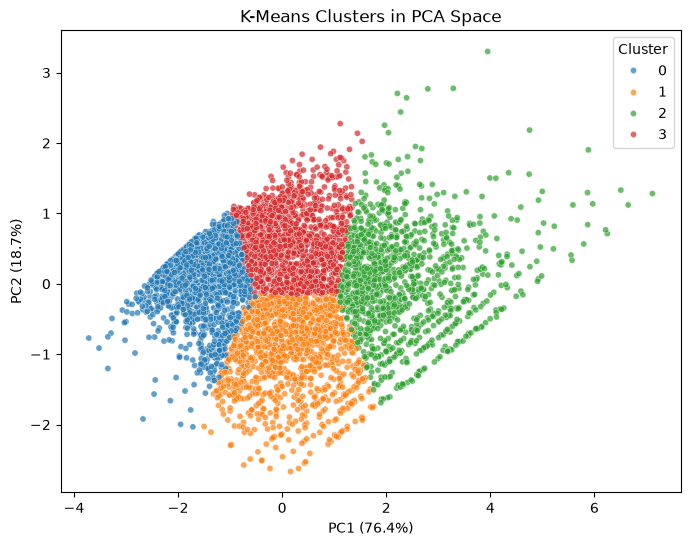

In [10]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X)
var = pca.explained_variance_ratio_
print("Explained variance:", var.round(3), "| Total:", round(var.sum() * 100, 1), "%")
print(pd.DataFrame(pca.components_, columns=['Recency', 'Frequency', 'Monetary'], index=['PC1', 'PC2']).round(2))

plt.figure(figsize=(8, 6))
sns.scatterplot(x=X_pca[:, 0], y=X_pca[:, 1], hue=rfm['Cluster'], palette='tab10', s=20, alpha=0.7)
plt.xlabel(f"PC1 ({var[0]*100:.1f}%)")
plt.ylabel(f"PC2 ({var[1]*100:.1f}%)")
plt.title("K-Means Clusters in PCA Space")
plt.show()




In [11]:
from sklearn.metrics import adjusted_rand_score

rfm['R_Score'] = pd.qcut(rfm['Recency'], q=4, labels=[4, 3, 2, 1]).astype(int)
rfm['F_Score'] = pd.qcut(rfm['Frequency'].rank(method='first'), q=4, labels=[1, 2, 3, 4]).astype(int)
rfm['M_Score'] = pd.qcut(rfm['Monetary'], q=4, labels=[1, 2, 3, 4]).astype(int)

def segment_customer(row):
    r, f, m = row['R_Score'], row['F_Score'], row['M_Score']
    if r >= 3 and f >= 3 and m >= 3: return 'VIP / Champions'
    elif r >= 3 and f <= 2:          return 'New & Potential'
    elif r <= 2 and f >= 3 and m >= 3: return 'At Risk (Loyal but leaving)'
    elif r <= 2 and f <= 2:          return 'Lost Customers'
    else:                            return 'Regulars'

rfm['Rule_Segment'] = rfm.apply(segment_customer, axis=1)

print(rfm['Rule_Segment'].value_counts())
print("\nAdjusted Rand Index:", round(adjusted_rand_score(rfm['Rule_Segment'], rfm['Cluster']), 3))
pd.crosstab(rfm['Rule_Segment'], rfm['Cluster'])


Rule_Segment
Lost Customers                 2045
VIP / Champions                1821
New & Potential                 894
At Risk (Loyal but leaving)     643
Regulars                        475
Name: count, dtype: int64

Adjusted Rand Index: 0.501


Cluster,0,1,2,3
Rule_Segment,,,,
At Risk (Loyal but leaving),0,0,44,599
Lost Customers,1754,1,0,290
New & Potential,153,692,2,47
Regulars,66,213,1,195
VIP / Champions,0,344,1149,328


In [12]:
base = rfm['Cluster'].values
aris = []
for seed in range(1, 11):
    labels = KMeans(n_clusters=4, n_init=10, random_state=seed).fit_predict(X)
    aris.append(adjusted_rand_score(base, labels))

print("ARI vs. main model across 10 seeds -> mean:", round(np.mean(aris), 3), "| min:", round(np.min(aris), 3))


ARI vs. main model across 10 seeds -> mean: 0.993 | min: 0.99


In [13]:
cluster_names = {2: 'Champions', 3: 'Lapsing Loyalists', 1: 'Recent Low-Spenders', 0: 'Dormant'}
rfm['Segment_Name'] = rfm['Cluster'].map(cluster_names)
rfm.reset_index().to_csv("RFM_KMeans_Final.csv", index=False)
rfm['Segment_Name'].value_counts()

Segment_Name
Dormant                1973
Lapsing Loyalists      1459
Recent Low-Spenders    1250
Champions              1196
Name: count, dtype: int64

In [14]:
print(df_clean['InvoiceDate'].min(), df_clean['InvoiceDate'].max())

2009-12-01 07:45:00 2011-12-09 12:50:00


every 5% of the Lapsing Loyalists' historical spend that is recovered equals about £142K. Every 1% of Champion revenue retained equals about £128K.


# E-Commerce Customer Segmentation using K-Means Clustering

## 1. Objective
Segment customers of a UK-based online retailer using RFM (Recency, Frequency, Monetary) features and unsupervised machine learning, then translate the segments into targeted marketing actions.

## 2. Data and Preparation
- Source: Online Retail II transaction data, [start date] to [end date]. Currency: GBP.
- 1,067,371 raw rows reduced to 779,425 after removing missing customer IDs, cancelled invoices, non-positive quantities and prices, and duplicates.
- 5,878 unique customers.
- RFM features were computed against a snapshot date one day after the last transaction.
- Skewness was reduced with a log1p transform (Monetary 25.07 to 0.27, Frequency 12.64 to 1.00, Recency 0.89 to -0.49), then features were standardized with StandardScaler.

## 3. Modeling
- K-Means was run for k = 2 to 10 with n_init=10 and random_state=42.
- k was selected using three criteria: elbow (inertia), silhouette score, and Davies-Bouldin index.
- k = 2 scored highest on silhouette (0.439) but only separates active from inactive customers, which is not actionable. k = 4 is the best-scoring option among k >= 3 (silhouette 0.365, Davies-Bouldin 0.93) and gives interpretable, distinct segments.

## 4. Validation
- Stability: refitting with 10 different random seeds gave a mean Adjusted Rand Index of 0.993 (minimum 0.990) against the main model, so the segments are stable.
- PCA: two components retain 95.1% of variance (PC1 76.4%, PC2 18.7%). PC1 behaves as an engagement and value axis; PC2 is mainly recency. The 2D plot is consistent with the cluster profiles.
- Benchmark: agreement with rule-based RFM quartile segments is moderate (Adjusted Rand Index = 0.50). 96% of K-Means Champions are rule-based VIPs, but K-Means yields a tighter group (1,196 vs. 1,821 rule-based VIPs).
- Quality note: silhouette of 0.365 indicates moderate structure. RFM data is a continuum, so neighboring segments overlap.

## 5. Segment Profiles
| Segment | Customers | Avg Recency (days) | Avg Frequency | Avg Spend | Revenue | Revenue Share |
|---|---|---|---|---|---|---|
| Champions | 1,196 (20.4%) | 27.7 | 19.3 | 10,731 | 12.83M | 73.9% |
| Lapsing Loyalists | 1,459 (24.8%) | 230.1 | 5.1 | 1,949 | 2.84M | 16.4% |
| Recent Low-Spenders | 1,250 (21.3%) | 28.3 | 3.1 | 857 | 1.07M | 6.2% |
| Dormant | 1,973 (33.6%) | 395.0 | 1.4 | 317 | 0.63M | 3.6% |

## 6. Key Insights
1. Revenue is highly concentrated: 20% of customers generate about 74% of revenue, and their average spend is roughly 34 times that of Dormant customers.
2. Lapsing Loyalists are the main revenue leak: proven buyers (about 5 orders) who have been inactive for about 230 days and hold 2.84M in historical revenue.
3. Dormant customers are the largest group (34%) but contribute only 3.6% of revenue.
4. Recent Low-Spenders are engaged but low-value, so they are the natural growth pool.

## 7. Business Recommendations
- Champions: loyalty tier, early access to new products, dedicated support; avoid blanket discounts.
- Lapsing Loyalists: personalized win-back campaign with a time-limited offer, prioritized by past spend. Illustrative impact: every 5% of their historical spend recovered is about 142K.
- Recent Low-Spenders: onboarding emails, cross-sell bundles, and incentives for a second and third purchase.
- Dormant: low-cost newsletter only; stop paid retargeting.

## 8. Limitations and Next Steps
- Segments describe past behavior and do not forecast future value.
- Roughly two years of data, so seasonality is not modeled.
- Next steps: compare with Gaussian Mixture Models, build a CLV model (BG/NBD + Gamma-Gamma), and refresh segments on a regular schedule as customers migrate between them.

## 9. Output
Final segmented customer table exported as RFM_KMeans_Final.csv for Power BI dashboards.